# The $1.50 hot dog that beat inflation? 🌭
### "Costco froze the combo since 1985 — and the stock crushes inflation, so buy COST", in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Real-price_erosion: Confirmed](https://img.shields.io/badge/Real--price_erosion-Confirmed-8b949e?style=flat-square)

It's one of the great retail legends: the Costco **hot-dog-and-soda combo has cost $1.50 since 1985** — through Volcker's hangover, three recessions, and the worst inflation in 40 years. The internet loves it as an *anti-inflation* mascot. And the leap the story quietly makes is: *Costco has such pricing power that its stock outruns inflation and the market too — so just buy COST as your inflation hedge.*

This notebook separates the part that's **true** from the part that's a **story**. Yes, the $1.50 combo really has melted in real terms. Yes, COST has been a phenomenal stock. But does COST actually *hedge inflation* — does it move up when inflation surprises to the upside — any better than a boring can-of-soup staples fund? That last claim is the only tradable one, and it's the one we test.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo null and the inflation-beta regressions? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** CPI here is the **real** FRED/BLS `CPIAUCSL` series (BLS `CUSR0000SA0`), fetched from the BLS public API and cached (one point, 2025-10, interpolated — the SA suspension). COST, SPY and XLP are real month-end total-return prices via yfinance. Every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # quantlab (optional)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hotdog_index import data, strategy as st

CPI = data.load_cpi()                                # REAL FRED/BLS CPIAUCSL (BLS CUSR0000SA0)
PANEL = data.build_panel()                           # empty if the COST/SPY/XLP cache is absent
HAVE = not PANEL.empty
print("market cache present:", HAVE, "| CPI months:", CPI.index[0].date(), "->", CPI.index[-1].date())

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2000-01 → 2026-06', 'n': 318, 'asof': '2026-06-30', 'fp': 'cbd3b6799d57', 'years': 26.5, 'combo': 1.5, 'base_year': 1985, 'cpi_1985': 107.6, 'cpi_now': 332.57, 'cpi_mult': 3.09, 'real_now': 0.49, 'eroded_pct': 67.6, 'infl_adj': 4.64, 'giveaway': 3.14, 'cost_mult': 28.7, 'cost_cagr': 13.5, 'cost_real': 14.6, 'cost_10k': 286935, 'spy_mult': 8.5, 'spy_cagr': 8.4, 'spy_real': 4.3, 'spy_10k': 85393, 'cpi_mult_win': 2.0, 'cpi_cagr': 2.6, 'cpi_10k': 19644, 'xlp_mult': 6.75, 'yoy_peak': 9.0, 'cost_beta': 0.115, 'cost_beta_t': 0.13, 'cost_beta_r2': 0.01, 'spy_beta': 0.879, 'spy_beta_t': 1.27, 'xlp_beta': 0.302, 'xlp_beta_t': 0.72, 'cost_pred_t': 0.89, 'gap_xlp': -0.186, 'gap_xlp_t': -0.27, 'gap_spy_t': -1.45, 'gap_spy_pred_t': 1.75, 'gap_xlp_pred_t': 1.43, 'costspy_alpha_t': 1.37, 'placebo_p': 0.88, 'era_early_t': -0.05, 'era_late_t': 0.36, 'timer_sh': 0.34, 'cost_bh_sh': 0.46, 'spy_sh': 0.4, 'timer_switches': 4.1, 'timer_invested': 0.49, 'syn_edge': 8, 'syn_slope': 7.72, 'syn_t': 7.02, 'syn_gap_t': 6.05, 'syn_null_t': -0.24}


market cache present: True | CPI months: 2000-01-31 -> 2026-06-30


## The answer first

| Question | Answer |
|---|---|
| Has the $1.50 combo really lost value? | **Yes — dramatically.** In 1985 dollars it now costs about **\$0.49** — a **68%** real haircut. To hold its 1985 purchasing power it'd sell for **\$4.64**. |
| Has COST beaten inflation and the market? | **Yes — massively.** \$10,000 in COST (2000) became **\$286,935**, vs **\$85,393** in SPY and just **\$19,644** of CPI. |
| So is COST an *inflation hedge*? | **No.** When inflation *surprises* higher, COST barely budges (*t* = **0.13**) — and it's **no better than a boring staples fund** (gap *t* = **-0.27**). |
| Then why does the story feel true? | Because COST **went up a lot**, and we remember the winner. "It rose" and "it hedges inflation" are different claims. |

> The erosion is real. COST's returns are real. The **inflation-hedge trade** is a mirage — COST is a great *growth* stock, not an inflation shield.

## 1 · The claim

> *"Costco has frozen the hot-dog combo at $1.50 since 1985 — that's the pricing power of a membership juggernaut. So COST will protect you from inflation: its stock outruns CPI and the S&P regardless of the macro. Buy it as an inflation hedge."*

It's steelman-able. Costco leans on **recurring membership fees** (a near-annuity that resets with inflation) and legendary discipline, and it has genuinely trounced the market for decades. If any consumer name deserves an "inflation-proof" halo, it's this one.

## 2 · So what?

"Buy this one stock and you're hedged against inflation" is a big, specific promise — the kind that sells newsletters. But it bundles **three different claims**: (1) the frozen combo loses real value (arithmetic), (2) COST has beaten inflation historically (a fact about the past), and (3) COST *reacts* to inflation shocks in a protective way you can trade (a mechanism). Only (3) is an *inflation hedge*. (1) is a calculator. (2) is hindsight about a known winner. Let's look at all three — honestly.

## 3 · How would we even know?

Three honest checks:

1. **The calculator.** Deflate the frozen $1.50 by CPI — how much real value has it shed?
2. **The race.** Grow $10,000 in COST, in SPY, and by CPI since 2000 — who wins, and by how much *after* inflation?
3. **The hedge test.** When inflation *surprises* higher, does COST rise — and does it rise **more than a plain staples basket (XLP)**? That's what "pricing-power inflation hedge" actually predicts.

**What would make us say "tradable hedge"?** COST's inflation-surprise beta is positive, significant, beats staples, and holds across eras. Anything less and the halo is just a great stock we're admiring after the fact.

## 4 · The teardown — let's actually look

**First: the combo really has melted.** Deflate the frozen $1.50 into 1985 dollars.

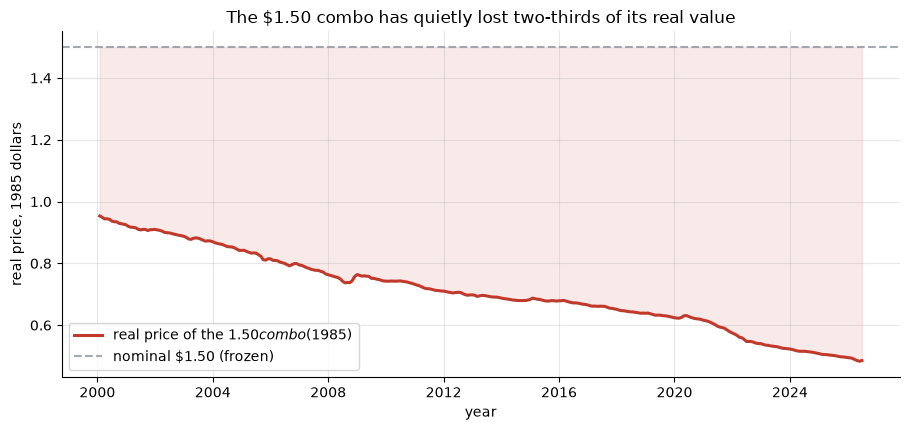

real price today ~$0.49  (down 68% since 1985)
to hold 1985 value it would cost $4.64  (Costco 'gives away' ~$3.14/combo)


In [2]:
rp = st.real_price(CPI, nominal=R['combo'], base_cpi=R['cpi_1985'])
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(rp.index, rp.values, c=RED, lw=2.2, label='real price of the $1.50 combo (1985 $)')
ax.axhline(R['combo'], ls='--', c=GREY, alpha=.8, label='nominal $1.50 (frozen)')
ax.fill_between(rp.index, rp.values, R['combo'], color=RED, alpha=.10)
ax.set_ylabel('real price, 1985 dollars'); ax.set_xlabel('year')
ax.set_title('The $1.50 combo has quietly lost two-thirds of its real value'); ax.legend()
plt.tight_layout(); plt.show()
print(f"real price today ~${R['real_now']:.2f}  (down {R['eroded_pct']:.0f}% since 1985)")
print(f"to hold 1985 value it would cost ${R['infl_adj']:.2f}  (Costco 'gives away' ~${R['giveaway']:.2f}/combo)")

Nobody disputes this part. In 1985 purchasing power the combo now costs about **\$0.49** — a **68%** real cut. But notice what this is: **pure arithmetic** from a frozen nominal price. It's a wonderful fact about Costco's *marketing*. It says nothing yet about its *stock*.

**Second: COST has crushed everything.** Grow $10,000 since 2000 in COST, in SPY, and by CPI.

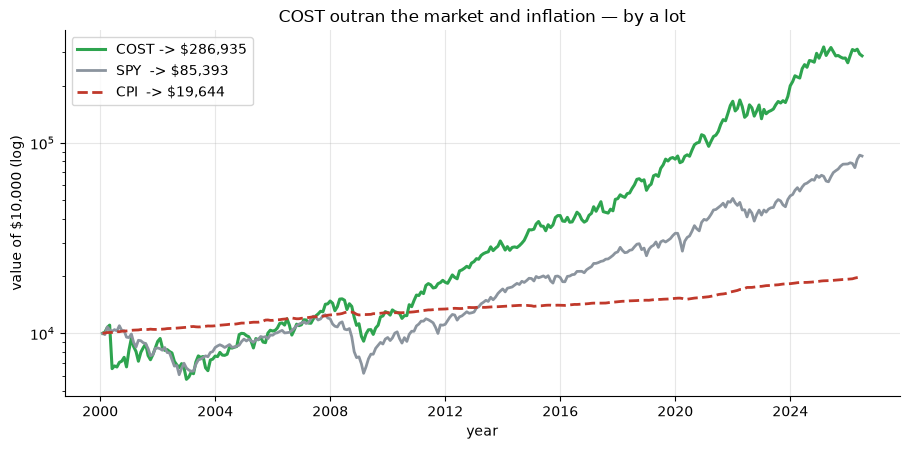

COST 29x  |  SPY 8x  |  CPI 2x  over 26 years


In [3]:
if HAVE:
    base = PANEL.index[0]
    cost = PANEL['cost']/PANEL['cost'].iloc[0]*10000
    spy  = PANEL['spy']/PANEL['spy'].iloc[0]*10000
    cpi  = PANEL['cpi']/PANEL['cpi'].iloc[0]*10000
    idx = PANEL.index
else:
    idx = pd.date_range('2000-01-31','2026-06-30',freq='ME')
    g=lambda c: 10000*(1+c/100)**(np.arange(len(idx))/12)
    cost, spy, cpi = g(R['cost_cagr']), g(R['spy_cagr']), g(R['cpi_cagr'])
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(idx, cost, c=GREEN, lw=2.2, label=f"COST -> ${R['cost_10k']:,.0f}")
ax.plot(idx, spy,  c=GREY,  lw=2.0, label=f"SPY  -> ${R['spy_10k']:,.0f}")
ax.plot(idx, cpi,  c=RED,   lw=2.0, ls='--', label=f"CPI  -> ${R['cpi_10k']:,.0f}")
ax.set_yscale('log'); ax.set_ylabel('value of $10,000 (log)'); ax.set_xlabel('year')
ax.set_title('COST outran the market and inflation — by a lot'); ax.legend()
plt.tight_layout(); plt.show()
print(f"COST {R['cost_mult']:.0f}x  |  SPY {R['spy_mult']:.0f}x  |  CPI {R['cpi_mult_win']:.0f}x  over {R['years']:.0f} years")

COST turned \$10k into **\$286,935** — a **15×** gain even *after* inflation. Case closed? Not so fast. This is one **hindsight-picked** stock we're admiring *because* it's the famous hot-dog company that won. "It went up" is not the same as "it protects you from inflation." For that, we need the hedge test.

**Third — the actual hedge test.** When inflation *surprises* to the upside (its yearly rate jumps), does COST rise? And does it beat a boring **consumer-staples** fund (XLP) at it?

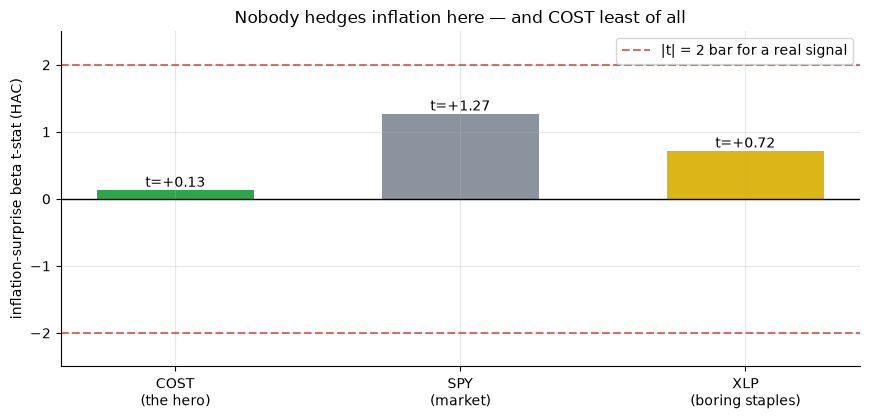

COST beta t=+0.13  (basically zero)  |  staples XLP t=+0.72
COST-minus-staples gap t=-0.27  ->  COST is NOT a better inflation hedge than a soup fund


In [4]:
if HAVE:
    cb = st.inflation_beta(PANEL,'cost'); sb = st.inflation_beta(PANEL,'spy'); xb = st.inflation_beta(PANEL,'xlp')
    ts = [cb['t_nw'], sb['t_nw'], xb['t_nw']]
else:
    ts = [R['cost_beta_t'], R['spy_beta_t'], R['xlp_beta_t']]
labs = ['COST\n(the hero)', 'SPY\n(market)', 'XLP\n(boring staples)']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labs, ts, .55, color=[GREEN, GREY, AMBER])
ax.axhline(2, ls='--', c=RED, alpha=.7, label='|t| = 2 bar for a real signal')
ax.axhline(-2, ls='--', c=RED, alpha=.7); ax.axhline(0, c='k', lw=1)
for i,t in enumerate(ts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('inflation-surprise beta t-stat (HAC)'); ax.set_ylim(-2.5, 2.5)
ax.set_title('Nobody hedges inflation here — and COST least of all'); ax.legend()
plt.tight_layout(); plt.show()
print(f"COST beta t={ts[0]:+.2f}  (basically zero)  |  staples XLP t={ts[2]:+.2f}")
print(f"COST-minus-staples gap t={R['gap_xlp_t']:+.2f}  ->  COST is NOT a better inflation hedge than a soup fund")

There it is. COST's response to inflation surprises is **statistically indistinguishable from zero** (*t* = 0.13), and it is **no better than a plain staples basket** — the COST-minus-XLP gap is a negative, insignificant **-0.27**. The one thing the "pricing-power inflation hedge" story actually predicts — a distinctive positive inflation beta — simply isn't in the tape.

## 5 · The verdict

- **Real-price erosion — Confirmed (but mechanical).** The $1.50 combo has shed **68%** of its real value; it'd cost **\$4.64** to keep 1985 purchasing power. True — and pure arithmetic.
- **Signal — None.** COST's inflation-surprise beta is essentially zero (*t* = 0.13) and no better than a boring staples fund (gap *t* = -0.27). No inflation-hedge mechanism.
- **Tradability — Mirage.** COST's huge win is a **hindsight-selected** growth story, not a repeatable inflation trade. Admiring the winner is not a strategy.

## 6 · Could you actually trade it? — the honest bottom line

"Fine," you say, "I'll hold COST only when inflation is heating up." Let's build exactly that — own COST when the inflation surprise is positive, cash otherwise — and race it against just buying and holding COST, and against SPY.

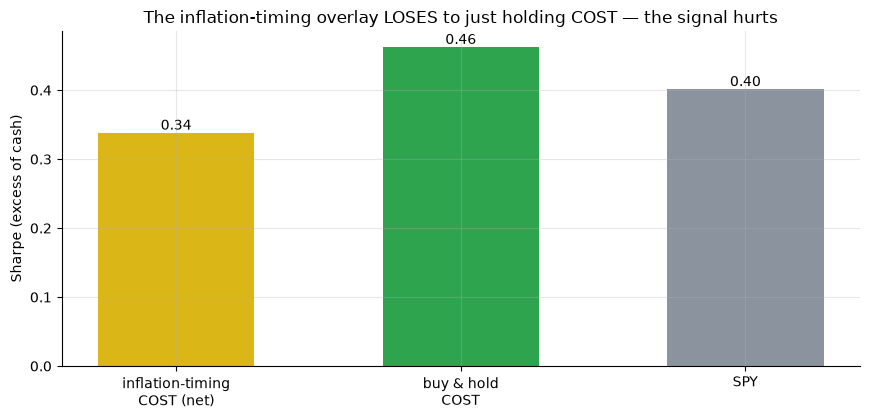

inflation-timing COST (net) Sharpe 0.34
buy & hold COST            Sharpe 0.46
SPY                        Sharpe 0.40


In [5]:
if HAVE:
    tm = st.timer_stats(PANEL, cost_bps=10.0)
    sh = {'inflation-timing\nCOST (net)': tm['timer_sharpe'], 'buy & hold\nCOST': tm['cost_bh_sharpe'], 'SPY': tm['spy_sharpe']}
else:
    sh = {'inflation-timing\nCOST (net)': R['timer_sh'], 'buy & hold\nCOST': R['cost_bh_sh'], 'SPY': R['spy_sh']}
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(list(sh), list(sh.values()), .55, color=[AMBER, GREEN, GREY])
for i,v in enumerate(sh.values()): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (excess of cash)'); ax.set_title('The inflation-timing overlay LOSES to just holding COST — the signal hurts')
plt.tight_layout(); plt.show()
for k,v in sh.items(): print(f'{k.replace(chr(10)," "):26s} Sharpe {v:.2f}')

The twist: the inflation-timing overlay (Sharpe **0.34**) actually **underperforms** simply buy-and-holding COST (**0.46**) — and even trails plain SPY (**0.40**). Timing on the inflation surprise *destroys* return: the signal forecasts nothing (we just saw that), so all the overlay does is **sit in cash through half of COST's compounding**. The only reason buy-hold COST beats SPY is that **COST is a spectacular hindsight-selected stock** — nothing to do with inflation. The "hedge" does negative work. That's a mirage.

## 7 · Going further 🚪

- **Use core CPI or PCE instead.** We already use the real `CPIAUCSL` (BLS `CUSR0000SA0`); swap in core CPI or PCE and re-run — a beta that's ~zero and inside its placebo won't wake up.
- **Try other 'pricing-power' names.** WMT, MCD, PG: does *any* consumer champion carry a real, distinctive inflation-surprise beta, or is "inflation-proof brand" always a story?
- **The survivorship trap.** We picked COST *because* it won. Re-run the race on a basket chosen in 2000 (not with hindsight) and watch the halo dim — see [docs/references.md](../docs/references.md).

*Think a consumer name genuinely hedges inflation shocks? Build it, measure the inflation-surprise beta, beat a staples control, and show it holds across eras — then charge it costs.*